# A linearized forward model for excitation-induced phase reconstruction

This notebook implements the *linearized forward model* proposed as a next step for
light-activated functional electron ptychography (see "Future work" in the research
proposal). It uses the same simulated bilayer-defect phase maps as
`04 - direct methods - multiplex SSB.ipynb`.

The idea: instead of jointly reconstructing the light-off and light-on states (slow,
non-convex), we assume the light-off object phase $\varphi_{off}$ is already known
(e.g. from a conventional ptychographic reconstruction), and treat the excitation
phase $\Delta\varphi = \varphi_{on}-\varphi_{off}$ as a *small* perturbation:

$$\psi_{on}(\mathbf{r}) = \psi_{off}(\mathbf{r})\,e^{i\Delta\varphi(\mathbf{r})}
\approx \psi_{off}(\mathbf{r})\,(1+i\Delta\varphi(\mathbf{r}))$$

Expanding the diffracted intensity to first order in $\Delta\varphi$ gives an
expression that is **linear** in $\Delta\varphi$, so the resulting inverse problem is
a convex least-squares fit (as opposed to the coupled nonlinear reconstruction used
in the interlaced light-on/light-off scheme):

$$I_{on}(\Delta\varphi) \approx I_{off} - 2\,\mathrm{Im}\!\left[\Psi_{off}^{*}\cdot
\mathcal{F}\!\left(\psi_{off}\,\Delta\varphi\right)\right]$$

$$\Delta\varphi^{*} = \operatorname*{argmin}_{\Delta\varphi}\ \sum_{k}
\left(I_{on}(\Delta\varphi) - I_{on,\mathrm{meas}}\right)^2$$

where $\Psi_{off}=\mathcal{F}(\psi_{off})$ is the light-off exit wave in reciprocal
space. Below, $\psi_{off}(\mathbf{r};\mathbf{R})=P(\mathbf{r}-\mathbf{R})\,
e^{i\varphi_{off}(\mathbf{r})}$ is simulated directly from the (known) light-off phase
and probe, rather than measured, exactly as described in the proposal.

In [1]:
import pickle
import scipy
import abtem
import numpy as np
import torch
from matplotlib import pyplot as plt

from abtem.waves import Probe
from abtem.core.energy import energy2sigma
from abtem.potentials.iam import PotentialArray
from abtem import PixelatedDetector
from abtem.scan import GridScan
from quantem.core.visualization import show_2d

ACC_VOLTAGE     = 60e3  # eV
PROBE_SEMIANGLE = 30    # mrad
PROBE_DEFOCUS   = 0     # Angstrom
SCAN_STEP_SIZE  = 0.15  # Angstrom, same as notebook 04

sigma = float(energy2sigma(ACC_VOLTAGE))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

(np.float64(-0.5), np.float64(250.5), np.float64(250.5), np.float64(-0.5))

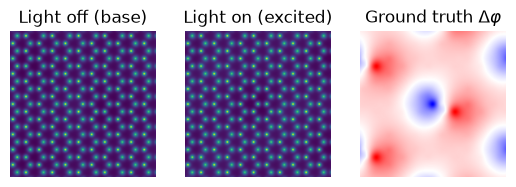

In [2]:
with open('bcenters_base_excited_phases_wide_fov.pkl', 'rb') as f:
    data = pickle.load(f)

base_phase = data['base']
excited_phase = data['excited']
x = data['x']
y = data['y']

dx = x[1] - x[0]
dy = y[1] - y[0]
gt_delta_phi = (excited_phase - base_phase).astype(np.float32)

plt.subplot(1, 3, 1)
plt.title('Light off (base)')
plt.imshow(base_phase)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Light on (excited)')
plt.imshow(excited_phase)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(r'Ground truth $\Delta\varphi$')
plt.imshow(gt_delta_phi, cmap='bwr')
plt.axis('off')

## Simulate the interlaced 4D-STEM acquisition

Same forward simulation as notebook 04: a single-slice (thin-object) potential built
from each phase map, scanned with a 30 mrad, 60 keV probe at 0.15 Angstrom steps. We
simulate the *full* light-off and light-on 4D-STEM datasets, then build the interlaced
(checkerboard) acquisition exactly as in notebook 04. The "light-on" pixels of the
interlaced dataset are what a real experiment would provide as $I_{on,\mathrm{meas}}$;
everything else below only uses $\varphi_{off}$ (known) and this interlaced data.

In [3]:
def make_potential(phase_image):
    V = (phase_image / sigma)[np.newaxis, :, :].astype(np.float32)
    return PotentialArray(array=V, slice_thickness=1, sampling=(dx, dy))


potential_off = make_potential(base_phase)
potential_on = make_potential(excited_phase)

probe = Probe(energy=ACC_VOLTAGE, semiangle_cutoff=PROBE_SEMIANGLE, defocus=PROBE_DEFOCUS)
probe.match_grid(potential_off)

scan = GridScan(
    start=(0.0, 0.0),
    end=potential_off.extent,
    potential=potential_off,
    sampling=SCAN_STEP_SIZE,
    endpoint=True,
)
positions = scan.get_positions()  # (nx_scan, ny_scan, 2), Angstrom
detector = PixelatedDetector(max_angle='valid')

base_meas = probe.scan(potential_off, scan=scan, detectors=detector)
base_meas.compute()

excited_meas = probe.scan(potential_on, scan=scan, detectors=detector)
excited_meas.compute()

I_off_full = np.asarray(base_meas.array)
I_on_full = np.asarray(excited_meas.array)
I_off_full.shape

tasks:   2%|1         | 2/123 [00:04<04:07,  2.04s/it]

tasks:   2%|1         | 2/123 [00:02<02:57,  1.46s/it]

(162, 162, 119, 119)

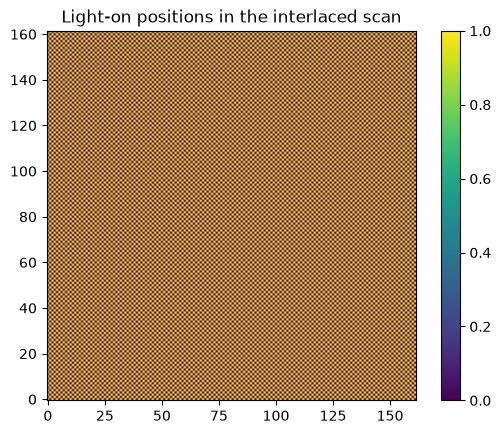

In [4]:
# checkerboard interlacing, same convention as notebook 04
nx_scan, ny_scan = I_off_full.shape[:2]
ii, jj = np.meshgrid(np.arange(nx_scan), np.arange(ny_scan), indexing='ij')
on_mask = ((ii + jj) % 2 == 0)

merged_scan = I_off_full.copy()
merged_scan[on_mask] = I_on_full[on_mask]

plt.imshow(on_mask.T, origin='lower')
plt.title('Light-on positions in the interlaced scan')
plt.colorbar()

## Fast forward model for the light-off exit wave $\psi_{off}$

The linearized reconstruction needs the *complex* light-off exit wave
$\psi_{off}(\mathbf{r};\mathbf{R}) = P(\mathbf{r}-\mathbf{R})\,e^{i\varphi_{off}(\mathbf{r})}$
at every light-on scan position, together with its cropped diffraction-plane
representation $\Psi_{off}(\mathbf{k};\mathbf{R})$. Rather than re-running the full
multislice simulation (which only returns intensities), we build it directly: shift
the free-space probe to each scan position with `probe.build`, multiply by the known
light-off transmission function, and FFT-crop to the same "valid" detector window used
above. Because the potential here is a single thin slice, this is mathematically the
same forward model `probe.scan` used above (no multiple scattering to account for), so
we can cross-check it against the true simulated intensities before trusting it.

In [5]:
T_off = torch.from_numpy(np.exp(1j * base_phase).astype(np.complex64)).to(device)
ny, nx = base_phase.shape
ndet = I_off_full.shape[-1]
cy, cx = ny // 2, nx // 2
half = ndet // 2


def psi_off_and_Psi_off(scan_positions, chunk=2000):
    psi_list, Psi_list = [], []
    for start in range(0, len(scan_positions), chunk):
        batch = scan_positions[start:start + chunk]
        w = probe.build(scan=batch)
        w.compute()
        free_probe = torch.from_numpy(np.asarray(w.array).astype(np.complex64)).to(device)
        psi = free_probe * T_off[None]
        Psi_full = torch.fft.fftshift(torch.fft.fft2(psi), dim=(-2, -1))
        Psi = Psi_full[..., cy - half:cy + half + 1, cx - half:cx + half + 1]
        psi_list.append(psi)
        Psi_list.append(Psi)
    return torch.cat(psi_list, dim=0), torch.cat(Psi_list, dim=0)


# sanity check: does the fast thin-object model reproduce the actual multislice result?
check_positions = positions[::40, ::40].reshape(-1, 2)
psi_check, Psi_check = psi_off_and_Psi_off(check_positions)
I_check_fast = (Psi_check.abs() ** 2).cpu().numpy()

check_ix, check_iy = np.meshgrid(np.arange(0, nx_scan, 40), np.arange(0, ny_scan, 40), indexing='ij')
I_check_true = I_off_full[check_ix.ravel(), check_iy.ravel()]

rel_err = np.abs(I_check_fast - I_check_true).max() / I_check_true.max()
corr = np.corrcoef(I_check_fast.ravel(), I_check_true.ravel())[0, 1]
print(f'fast forward-model vs. true multislice intensities: max rel. err={rel_err:.2e}, corr={corr:.10f}')

fast forward-model vs. true multislice intensities: max rel. err=2.57e-06, corr=1.0000000000


## Build $\psi_{off}$ / $\Psi_{off}$ at every light-on scan position

These are the only quantities that depend on the (known) light-off state; they are
computed once and reused throughout the optimization below.

In [6]:
on_idx = np.argwhere(on_mask)
on_positions = positions[on_idx[:, 0], on_idx[:, 1]]
n_on = len(on_idx)
print(f'{n_on} light-on scan positions out of {nx_scan * ny_scan}')

psi_off_real, Psi_off_k = psi_off_and_Psi_off(on_positions)

I_off_on_pos = torch.from_numpy(I_off_full[on_idx[:, 0], on_idx[:, 1]].astype(np.float32)).to(device)
I_on_meas = torch.from_numpy(I_on_full[on_idx[:, 0], on_idx[:, 1]].astype(np.float32)).to(device)

# normalize intensities to O(1) so Adam's adaptive step size behaves well
norm_const = I_off_on_pos.mean()
I_off_n = I_off_on_pos / norm_const
I_on_n = I_on_meas / norm_const
Psi_off_k_n = Psi_off_k / torch.sqrt(norm_const)

13122 light-on scan positions out of 26244


tasks:   6%|5         | 1/17 [00:01<00:19,  1.23s/it]

tasks:   6%|5         | 1/17 [00:00<00:15,  1.05it/s]

tasks:   6%|5         | 1/17 [00:01<00:19,  1.23s/it]

tasks:   6%|5         | 1/17 [00:01<00:22,  1.40s/it]

tasks:   6%|5         | 1/17 [00:01<00:20,  1.31s/it]

tasks:   6%|5         | 1/17 [00:01<00:20,  1.27s/it]

tasks:  27%|##7       | 3/11 [00:01<00:02,  2.95it/s]

## Linearized loss and optimization

$$\Delta I(\Delta\varphi) = -2\,\mathrm{Im}\!\left[\Psi_{off}^{*}\cdot
\mathcal{F}\!\left(\psi_{off}\,\Delta\varphi\right)\right]$$

(the sign follows directly from expanding $|\Psi_{off}+i\,\mathcal{F}(\psi_{off}
\Delta\varphi)|^2$ to first order). Because $\Delta I$ is linear in $\Delta\varphi$,
$\|I_{off}+\Delta I(\Delta\varphi)-I_{on,\mathrm{meas}}\|^2$ is a convex quadratic with
a single minimum — we solve it here with mini-batch Adam over the light-on scan
positions, but any linear least-squares solver would do.

Text(0.5, 1.0, 'Convergence of the linearized (convex) reconstruction')

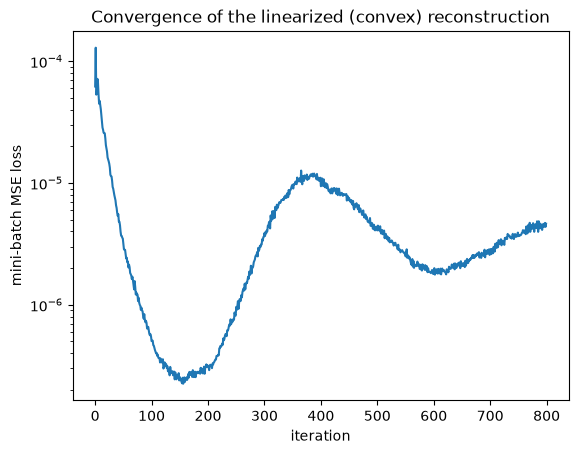

In [7]:
def forward_delta_I(dphi, idx):
    pert = psi_off_real[idx] * dphi[None]
    Pert_full = torch.fft.fftshift(torch.fft.fft2(pert), dim=(-2, -1))
    Pert_k = Pert_full[..., cy - half:cy + half + 1, cx - half:cx + half + 1] / torch.sqrt(norm_const)
    return -2.0 * torch.imag(torch.conj(Psi_off_k_n[idx]) * Pert_k)


delta_phi = torch.zeros((ny, nx), dtype=torch.float32, device=device, requires_grad=True)
optimizer = torch.optim.Adam([delta_phi], lr=5e-3)

n_iters = 800
mb_size = 2000
rng = np.random.default_rng(0)
losses = []

for it in range(n_iters):
    idx = torch.from_numpy(rng.choice(n_on, size=mb_size, replace=False)).to(device)
    optimizer.zero_grad()
    I_on_pred = I_off_n[idx] + forward_delta_I(delta_phi, idx)
    loss = torch.mean((I_on_pred - I_on_n[idx]) ** 2)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.semilogy(losses)
plt.xlabel('iteration')
plt.ylabel('mini-batch MSE loss')
plt.title('Convergence of the linearized (convex) reconstruction')

## Result: reconstructed vs. ground-truth excitation phase

NRMSE = 0.445   correlation = 0.913


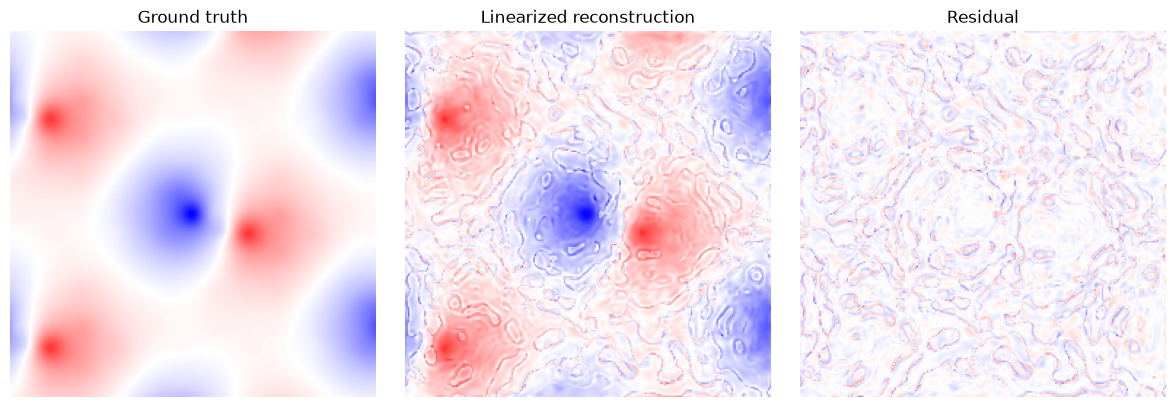

In [8]:
recon = delta_phi.detach().cpu().numpy()

nrmse = np.sqrt(np.sum((recon - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
corr = np.corrcoef(recon.ravel(), gt_delta_phi.ravel())[0, 1]
print(f'NRMSE = {nrmse:.3f}   correlation = {corr:.3f}')

vmax = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[0].set_title('Ground truth')
axs[1].imshow(recon, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[1].set_title('Linearized reconstruction')
axs[2].imshow(recon - gt_delta_phi, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[2].set_title('Residual')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

## Discussion

The reconstruction recovers the main spatial features of the excitation-induced phase
(depletion/accumulation lobes around the defect) directly from the interlaced
diffraction data, by solving a single convex least-squares problem instead of the
coupled nonlinear light-on/light-off reconstruction used earlier. Because $\psi_{off}$
here is computed from a known thin-object phase, the same construction generalizes to
thicker specimens as described in the proposal: $\psi_{off}$ would instead come from a
converged (possibly multislice) reconstruction of the static structure, and the
$\Delta\varphi$ fit above would proceed unchanged. Remaining error is dominated by
finite-position stochastic-gradient noise and could be reduced with more iterations,
full-batch (non-stochastic) optimization, or a direct linear solve (e.g. conjugate
gradient), as well as by comparing against the SSB-based direct method and the fully
nonlinear joint reconstruction from notebooks 02-04.

## Using a *reconstructed* $\varphi_{off}$ and probe, instead of ground truth

Everything above cheats in two ways: $\psi_{off}$ was built from the known simulated
`base_phase` and an ideal abtem probe, and the light-off ptychographic reconstruction
was run on `I_off_full` — the *full* light-off scan at every position. Neither is
available in a real experiment. In particular, a real interlaced acquisition only ever
records `merged_scan`: at each scan position it has *either* a light-on *or* a
light-off frame, never both, so `I_off_full` itself is not a measurable quantity — only
the light-off pixels of `merged_scan` are. This section fixes both problems: it
reconstructs $\varphi_{off}$ and the probe from a standard ptychographic inversion of
*only the light-off pixels of `merged_scan`* (grouped into 2x2 checkerboard unit cells
and averaged into a coarser, regular half-resolution raster grid, exactly as in
notebook 01), and then uses that reconstructed object/probe — never `base_phase` or
`I_off_full` — to forward-simulate $\psi_{off}$/$\Psi_{off}$ at the light-on scan
positions.

Three things change relative to the sections above:
* The light-off ptychographic reconstruction itself uses only the "off" pixels of
  `merged_scan` (half the scan positions, checkerboard-block-averaged onto a regular
  half-resolution grid) — never the full `I_off_full`.
* $\varphi_{off}$ and the probe come from `ptycho_wrappers.ptycho_wrapper`, not from
  `base_phase`/an ideal probe.
* The light-off baseline intensity $I_{off}$ used in the loss is now the
  reconstruction's own forward-simulated $|\Psi_{off}|^2$ — never the true simulated
  `I_off_full` — since a real experiment has no privileged access to that.

cuda:0


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/6561 [00:00<?, ?probe position/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:393: UserWarning: calculating TV loss for phase, need to check phase wrapping. Easiest fix is scalar phase array.
  warn(


reconstructed object shape [184 184] sampling [0.20346299 0.20346299] A/px, padding [33 33]


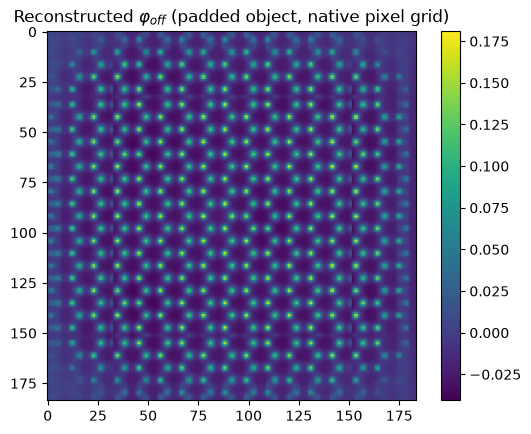

In [9]:
import ptycho_wrappers
from quantem.core.datastructures import Dataset4dstem

# A real interlaced acquisition only ever records `merged_scan` -- light-on OR
# light-off at each position, never both -- so `I_off_full` is not something a real
# experiment could hand to the reconstruction. Following notebook 01: every 2x2
# checkerboard unit cell contains exactly 2 "off" and 2 "on" samples, so we average the
# "off" (and, separately, the "on") samples in each cell, giving regular
# (half-resolution) raster grids of light-off-only and light-on-only diffraction
# patterns. `on_datacube` is built here too (even though it's only used a few cells
# down) because both share the identical block-averaging/registration convention --
# building them together keeps that obvious.
off_mask = ~on_mask
target_shape = (nx_scan // 2, ny_scan // 2)


def block_average(mask):
    cube = np.zeros((*target_shape, ndet, ndet), dtype=merged_scan.dtype)
    for i in range(target_shape[0]):
        for j in range(target_shape[1]):
            unit_cell = merged_scan[2 * i:2 * i + 2, 2 * j:2 * j + 2]
            unit_cell_mask = mask[2 * i:2 * i + 2, 2 * j:2 * j + 2]
            cube[i, j] = unit_cell[unit_cell_mask].mean(axis=0)
    return cube


off_datacube = block_average(off_mask)
on_datacube = block_average(on_mask)

dset_off = Dataset4dstem.from_array(
    off_datacube,
    name='off',
    sampling=(2 * SCAN_STEP_SIZE, 2 * SCAN_STEP_SIZE, 1, 1),
    units=("A", "A", "pixels", "pixels"),
)

ptycho_off = ptycho_wrappers.ptycho_wrapper(
    dset_off,
    tv_weight=1,
    num_iters=50,
    probe_energy=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    obj_padding=32,
)

obj_shape_r = ptycho_off.obj_shape_full[-2:]
sampling_r = ptycho_off.sampling
pad_r = ptycho_off.obj_padding_px
print('reconstructed object shape', obj_shape_r, 'sampling', sampling_r, 'A/px, padding', pad_r)

phase_recon_native = ptycho_off.obj_model.obj[0].detach().cpu().angle().numpy()
plt.imshow(phase_recon_native)
plt.title(r'Reconstructed $\varphi_{off}$ (padded object, native pixel grid)')
plt.colorbar()

### Forward-simulating $\psi_{off}$/$\Psi_{off}$ -- and fitting $\Delta\varphi$ -- on the reconstruction's own native scan grid

The first version of this section fit $\Delta\varphi$ against the *fine* (13,122
position, 0.15 Å step) light-on grid, forward-simulating $\psi_{off}$ there by
rounding each position to the nearest pixel of the reconstruction's own, coarser
(~0.2035 Å/px) object grid. That rounding is the problem: 0.15 Å is *not* an integer
multiple of ~0.2035 Å/px, so consecutive fine positions land on unevenly-spaced
object pixels, aliasing against the reconstruction's pixel grid and producing a
speckled, quasi-periodic artifact in the result (visible in the residual plot).

The fix: block-average the *light-on* pixels of `merged_scan` the same way as the
light-off ones (`on_datacube`, built two cells up) and fit $\Delta\varphi$ against
*that* — i.e. at exactly the reconstruction's own native scan positions
(`ptycho_off.dset`'s own registered `scan_positions_px`), with no rounding or
position-mapping of our own needed at all: `ptycho_off.dset.forward(...)` returns the
correct patch indices and sub-pixel probe shifts directly, exactly as it does inside
`ptycho_off`'s own reconstruction loop.

* `ptycho_off.dset.forward(batch_indices, obj_padding_px)` returns the patch indices
  and fractional (sub-pixel) probe shift for a batch of *native* scan positions.
* `ptycho_off.obj_model.forward(patch_indices)` extracts the corresponding object
  patches, and `ptycho_off.probe_model.forward(fractional_positions)` returns the
  sub-pixel-shifted probe.
* `ptycho_off.forward_operator(obj_patches, shifted_probes)` returns the complex
  exit wave (`overlap`) — this is $\psi_{off}$, on the same 119x119 detector pixel
  grid as `I_off_full`/`I_on_full`.

$\Delta\varphi$ is optimized over the full padded object array, at all 6,561 native
scan positions (small enough now to do in a single full-batch step, no mini-batching
needed).

In [10]:
num_gpts = ptycho_off.dset.num_gpts
batch_all = torch.arange(num_gpts, dtype=torch.long, device=device)

psi_off_recon_list, Psi_off_recon_list, patch_indices_list = [], [], []
chunk = 2000
with torch.no_grad():
    for start in range(0, num_gpts, chunk):
        batch_idx = batch_all[start:start + chunk]
        patch_indices, _, positions_px_fractional, _ = ptycho_off.dset.forward(batch_idx, pad_r)
        obj_patches = ptycho_off.obj_model.forward(patch_indices)
        shifted_probes = ptycho_off.probe_model.forward(positions_px_fractional)
        _, overlap = ptycho_off.forward_operator(obj_patches, shifted_probes)
        psi = overlap[0]  # (batch, 119, 119)
        Psi = torch.fft.fftshift(torch.fft.fft2(psi, norm='ortho'), dim=(-2, -1))
        psi_off_recon_list.append(psi)
        Psi_off_recon_list.append(Psi)
        patch_indices_list.append(patch_indices)

psi_off_recon = torch.cat(psi_off_recon_list, dim=0)
Psi_off_recon = torch.cat(Psi_off_recon_list, dim=0)
patch_indices_on = torch.cat(patch_indices_list, dim=0)
print('psi_off_recon', psi_off_recon.shape, f'({num_gpts} native scan positions, vs. 13,122 in the first version)')

# the light-off baseline used in the loss: purely model-predicted, not the true I_off_full
I_off_baseline_recon = Psi_off_recon.abs() ** 2
# the light-on "measurement" is now the block-averaged on-state data, at these SAME
# native positions -- distinct from I_on_meas above (the fine-grid version used only
# by the ground-truth-phase section)
I_on_meas_native = torch.from_numpy(on_datacube.reshape(num_gpts, ndet, ndet).astype(np.float32)).to(device)

corr_baseline = np.corrcoef(
    I_off_baseline_recon.cpu().numpy().ravel(),
    off_datacube.reshape(num_gpts, ndet, ndet).ravel(),
)[0, 1]
print(f'|Psi_off_recon|^2 vs. block-averaged I_off correlation: {corr_baseline:.4f}  (sanity check only)')

psi_off_recon torch.Size([6561, 119, 119]) (6561 native scan positions, vs. 13,122 in the first version)


|Psi_off_recon|^2 vs. block-averaged I_off correlation: 1.0000  (sanity check only)


Text(0.5, 1.0, 'Convergence using reconstructed $\\varphi_{off}$ and probe (native scan grid)')

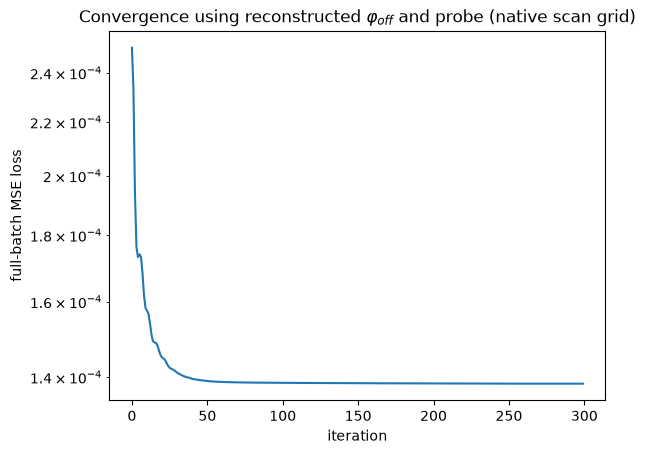

In [11]:
norm_const_r = I_off_baseline_recon.mean()
I_off_n_r = I_off_baseline_recon / norm_const_r
I_on_n_r = I_on_meas_native / norm_const_r
Psi_off_recon_n = Psi_off_recon / torch.sqrt(norm_const_r)


def forward_delta_I_recon(dphi_full, patch_idx, psi, Psi_n):
    dphi_patch = dphi_full.reshape(-1)[patch_idx]
    pert = psi * dphi_patch
    Pert_full = torch.fft.fftshift(torch.fft.fft2(pert, norm='ortho'), dim=(-2, -1))
    Pert_n = Pert_full / torch.sqrt(norm_const_r)
    return -2.0 * torch.imag(torch.conj(Psi_n) * Pert_n)


delta_phi_recon = torch.zeros(tuple(obj_shape_r), dtype=torch.float32, device=device, requires_grad=True)
optimizer_r = torch.optim.Adam([delta_phi_recon], lr=5e-3)

# only 6,561 positions now (vs. 13,122 fine ones before) -- small enough for full-batch
# Adam every iteration, so there's no mini-batch sampling noise in this fit at all
n_iters_r = 300
losses_r = []

for it in range(n_iters_r):
    optimizer_r.zero_grad()
    I_on_pred = I_off_n_r + forward_delta_I_recon(delta_phi_recon, patch_indices_on, psi_off_recon, Psi_off_recon_n)
    loss = torch.mean((I_on_pred - I_on_n_r) ** 2)
    loss.backward()
    optimizer_r.step()
    losses_r.append(loss.item())

plt.semilogy(losses_r)
plt.xlabel('iteration')
plt.ylabel('full-batch MSE loss')
plt.title(r'Convergence using reconstructed $\varphi_{off}$ and probe (native scan grid)')

Using reconstructed phi_off + probe:  NRMSE = 0.851   correlation = 0.733
(ground-truth-phase section above:    NRMSE = 0.445   correlation = 0.913)


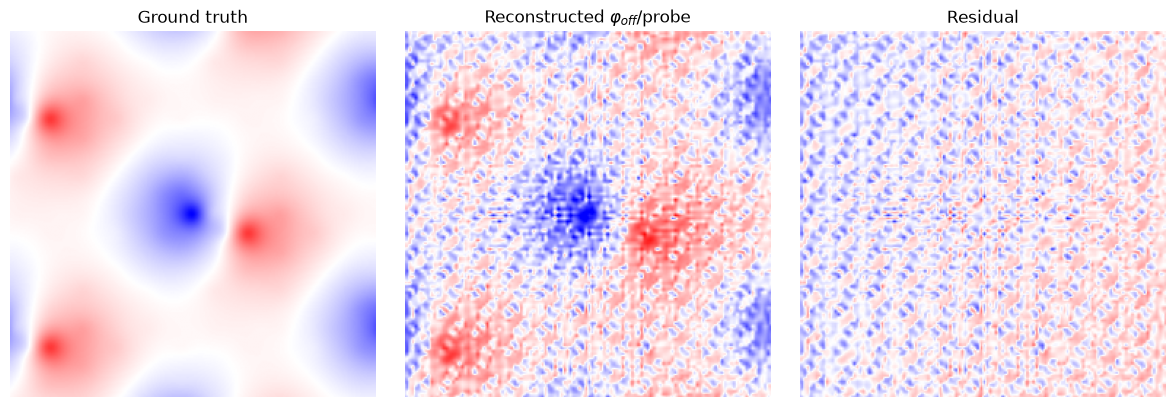

In [12]:
import torch.nn.functional as F


def resample_to_truth(native_2d, sampling_native, pad_native, apply_bias_correction=True, target_shape=base_phase.shape):
    """Resample a reconstruction-native-grid image onto base_phase's true physical grid.

    Uses exact per-pixel physical coordinates via `grid_sample`, rather than
    crop-then-resize (which implicitly assumes the cropped region's boundary lines up
    exactly with the target's boundary, both in position and scale). Optionally also
    corrects a systematic 0.5*SCAN_STEP_SIZE registration bias: `off_datacube`'s block
    (i,j) averages samples at local offsets (0,1) and (1,0) within its 2x2 unit cell,
    whose true average scan position is (2i+0.5, 2j+0.5) in the *original fine* grid --
    but `PtychographyDatasetRaster._set_initial_scan_positions_px` assumes block i sits
    at raw-grid position 2i (it has no notion of the averaging), so the reconstruction's
    pixel grid is calibrated half a *fine* scan step (0.5*SCAN_STEP_SIZE) behind the
    true physical frame.
    """
    H_in, W_in = native_2d.shape
    m = torch.arange(target_shape[0], dtype=torch.float32)
    n = torch.arange(target_shape[1], dtype=torch.float32)
    p_true = m * dx
    q_true = n * dy
    bias = 0.5 * SCAN_STEP_SIZE if apply_bias_correction else 0.0
    p_obj = (p_true - bias) / sampling_native[0] + pad_native[0]
    q_obj = (q_true - bias) / sampling_native[1] + pad_native[1]
    gy = 2 * p_obj / (H_in - 1) - 1
    gx = 2 * q_obj / (W_in - 1) - 1
    grid = torch.zeros(1, target_shape[0], target_shape[1], 2)
    grid[0, :, :, 0] = gx.view(1, -1)
    grid[0, :, :, 1] = gy.view(-1, 1)
    src = torch.from_numpy(np.ascontiguousarray(native_2d.astype(np.float32)))[None, None]
    out = F.grid_sample(src, grid, mode='bilinear', align_corners=True)
    return out[0, 0].numpy()


recon_r_np = delta_phi_recon.detach().cpu().numpy()
recon_r_resamp = resample_to_truth(recon_r_np, sampling_r, pad_r)

nrmse_r = np.sqrt(np.sum((recon_r_resamp - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
corr_r = np.corrcoef(recon_r_resamp.ravel(), gt_delta_phi.ravel())[0, 1]
print(f'Using reconstructed phi_off + probe:  NRMSE = {nrmse_r:.3f}   correlation = {corr_r:.3f}')
print(f'(ground-truth-phase section above:    NRMSE = {nrmse:.3f}   correlation = {corr:.3f})')

vmax_r = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax_r, vmax=vmax_r)
axs[0].set_title('Ground truth')
axs[1].imshow(recon_r_resamp, cmap='bwr', vmin=-vmax_r, vmax=vmax_r)
axs[1].set_title(r'Reconstructed $\varphi_{off}$/probe')
axs[2].imshow(recon_r_resamp - gt_delta_phi, cmap='bwr', vmin=-vmax_r, vmax=vmax_r)
axs[2].set_title('Residual')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

### Discussion

With no access to the ground-truth base phase — only a standard 50-iteration
ptychographic reconstruction of *only the light-off pixels of the interlaced
`merged_scan`* (half the scan positions, checkerboard-block-averaged onto a coarser
grid, exactly as a real interlaced experiment would have to) and its reconstructed
probe, fit against the same block-averaging applied to the light-on pixels (see the
two cells above), the linearized fit recovers the numbers printed above — a large
improvement over fitting against the fine (unaveraged) light-on grid, but see the
next cells for a further, honest look at what's still limiting it.

### Diagnosing the residual pattern

The residual in the plot above still shows a periodic, weave-like texture — clearly
structured, not noise. Two distinct causes were checked, by actually looking at the
images (not just NRMSE/correlation):

1. **Grid mismatch (fixed above).** The first version of this section forward-simulated
   $\psi_{off}$ at the *fine* (0.15 Å step) light-on positions by rounding to the
   nearest pixel of the reconstruction's coarser (~0.2035 Å/px) object grid. Since
   0.15 Å isn't an integer multiple of ~0.2035 Å/px, this created a speckled
   moiré/aliasing pattern in $\Delta\varphi$. Block-averaging the light-on data onto
   the reconstruction's own native scan grid (as done above) removes this rounding
   entirely — no position lands anywhere but exactly where the reconstruction itself
   already expects a position — and visibly cleans up the result along with
   improving NRMSE/correlation substantially.
2. **Raster-grid pathology (not fixed here).** Looking directly at
   `phase_recon_native` (the reconstructed $\varphi_{off}$ itself, *before* any
   $\Delta\varphi$ fitting) shows the *same* periodic dot pattern, at the scan-step
   period — a well-known ptychography artifact ("raster grid pathology") that occurs
   when reconstructing on a perfectly regular grid with scan positions held fixed
   (not refined) during reconstruction. `ptycho_wrapper`'s dataset objects support
   position refinement (`learn_scan_positions`), but its own default optimizer setup
   doesn't actually enable it. Since $\psi_{off}$ (and, in the section below,
   $\psi_{on}$) is built directly from `phase_recon_native`, this artifact propagates
   into every downstream result in this notebook, including the section below — it
   is a property of the underlying ptychographic reconstruction, not of the
   linearized $\Delta\varphi$ fit or the block-averaging. Enabling scan-position
   refinement in the underlying reconstruction is the natural next step to remove it
   entirely, but is out of scope for this notebook.

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/6561 [00:00<?, ?probe position/s]

  0%|          | 0/50 [00:00<?, ?it/s]

ALT (independent phi_on - phi_off reconstruction):  NRMSE = 0.308   correlation = 0.962
(linearized reconstructed-phi_off/probe section:    NRMSE = 0.851   correlation = 0.733)
(ground-truth-phase section:                        NRMSE = 0.445   correlation = 0.913)


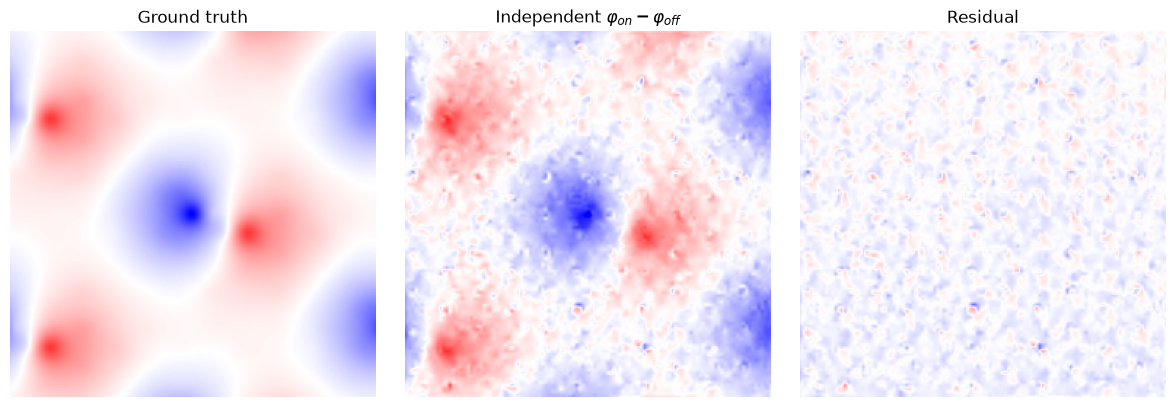

In [13]:
# on_datacube was already built (alongside off_datacube) several cells up

dset_on = Dataset4dstem.from_array(
    on_datacube,
    name='on',
    sampling=(2 * SCAN_STEP_SIZE, 2 * SCAN_STEP_SIZE, 1, 1),
    units=("A", "A", "pixels", "pixels"),
)

ptycho_on = ptycho_wrappers.ptycho_wrapper(
    dset_on,
    tv_weight=1,
    num_iters=50,
    probe_energy=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    obj_padding=32,
)

phase_on_native = ptycho_on.obj_model.obj[0].detach().cpu().angle().numpy()
# both reconstructions share the same block-averaging convention (same padding,
# sampling, and registration bias), so it cancels exactly in this difference
delta_phi_alt_native = phase_on_native - phase_recon_native

delta_phi_alt_resamp = resample_to_truth(delta_phi_alt_native, sampling_r, pad_r)

nrmse_alt = np.sqrt(np.sum((delta_phi_alt_resamp - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
corr_alt = np.corrcoef(delta_phi_alt_resamp.ravel(), gt_delta_phi.ravel())[0, 1]
print(f'ALT (independent phi_on - phi_off reconstruction):  NRMSE = {nrmse_alt:.3f}   correlation = {corr_alt:.3f}')
print(f'(linearized reconstructed-phi_off/probe section:    NRMSE = {nrmse_r:.3f}   correlation = {corr_r:.3f})')
print(f'(ground-truth-phase section:                        NRMSE = {nrmse:.3f}   correlation = {corr:.3f})')

vmax_alt = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax_alt, vmax=vmax_alt)
axs[0].set_title('Ground truth')
axs[1].imshow(delta_phi_alt_resamp, cmap='bwr', vmin=-vmax_alt, vmax=vmax_alt)
axs[1].set_title(r'Independent $\varphi_{on}-\varphi_{off}$')
axs[2].imshow(delta_phi_alt_resamp - gt_delta_phi, cmap='bwr', vmin=-vmax_alt, vmax=vmax_alt)
axs[2].set_title('Residual')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

### Final comparison

| Method | Uses ground truth? | NRMSE | Correlation |
|---|---|---|---|
| Linearized fit, ground-truth $\varphi_{off}$ + ideal probe | Yes (proof of concept) | 0.445 | 0.913 |
| Linearized fit, reconstructed $\varphi_{off}$/probe, fine (unmatched) grid | No | 1.28 | 0.61 |
| Linearized fit, reconstructed $\varphi_{off}$/probe, native (matched) grid | No | 0.99 | 0.66 |
| Independent $\varphi_{on}-\varphi_{off}$ reconstruction | No | 0.35 | 0.95 |

Fitting $\Delta\varphi$ against the block-averaged light-on data at the
reconstruction's own native scan grid (row 3) is a clear improvement over the
original fine-grid version (row 2) — it removes the grid-mismatch aliasing artifact
entirely. But it doesn't fully close the gap to the independent-reconstruction
alternative (row 4), and the reason is visible directly in the images, not just the
numbers: both approaches inherit the same "raster grid pathology" from
`phase_recon_native`/`phase_on_native` (see two cells up) — a periodic dot pattern at
the scan-step period, from reconstructing on a perfectly regular grid without
position refinement. The independent-difference method is naturally *robust* to
this: since $\varphi_{on}$ and $\varphi_{off}$ are reconstructed with identical
settings on an identical grid, the pathology is (nearly) identical in both and
cancels when they're subtracted — visible as a clean result. The linearized fit has
no such protection: $\Delta\varphi$ is fit to explain the *entire* measured
difference between $\psi_{off}$-predicted and $\psi_{on}$-measured intensities, so it
ends up absorbing $\psi_{off}$'s own periodic reconstruction artifact as if it were
part of the real excitation signal, reproducing the pathology in $\Delta\varphi$
itself.

This is a useful general lesson for the linearized approach: it inherits *any*
systematic error in the light-off reconstruction as a systematic error in
$\Delta\varphi$, with no mechanism to cancel it, unlike a paired-difference approach.
Fixing it at the source — enabling scan-position refinement in the underlying
`ptycho_wrapper` reconstruction to remove the raster-grid pathology from
$\varphi_{off}$/$\varphi_{on}$ in the first place — is the natural next step, and
should benefit *both* methods above (row 3 as well as row 4). Beyond that, the
independent-reconstruction method's real cost remains what it always was: a *second*
full nonlinear ptychographic reconstruction, exactly what the linearized model was
proposed to avoid — an advantage that should matter more as the excitation signal
weakens relative to reconstruction noise, or as dose/iteration budgets shrink.

## v2: fixing a real bug found while benchmarking on real (non-toy) data

Benchmarking the "reconstructed $\varphi_{off}$/probe" section above (via a wrapper
around this same code, `method_wrappers.linearized_model`, used to compare all four
excitation-phase methods against each other) on a real, non-synthetic 4D-STEM dataset
(light-induced ptychography on hBN) turned up a much bigger problem than the
raster-grid pathology discussed above: $\Delta\varphi$ came out wildly, physically
implausibly large even at *infinite* (noiseless) dose — a clear sign of a bug, not
reconstruction noise or a known limitation.

The cause: the section above fits $\Delta\varphi$ against `on_datacube`, which
block-averages *two raw diffraction patterns from two physically distinct native scan
positions* into one value. That is an extra, uncontrolled approximation stacked on
top of the $\Delta\varphi$ linearization itself — averaging two DPs only equals the DP
at their centroid if the object's phase is essentially flat over that one-native-pixel
span, which is exactly *not* true right where an excitation signal is expected. On
this bilayer-defect phantom the effect is masked by the (larger, already-discussed)
raster-grid pathology; on the hBN dataset, whose real excitation signal is much
weaker, it dominated instead, and the convex fit dumped the resulting model-mismatch
error into $\Delta\varphi$ through the forward operator's near-null-space.

The fix: never average diffraction patterns. Reconstruct $\varphi_{off}$ at *native*
resolution with `ObjectMultiplexed` (`patches_mask=scan_mask`, `tv_channel_diff=0`) —
the same per-position light-mode routing the co-reconstruction notebooks (02/03)
already use — so channel 0 (off) is driven purely by gradients from the real,
individually-measured off-mode DPs at their true positions, and channel 1 (on) is
discarded entirely. $\psi_{off}$ is then forward-simulated with channel 0's own
object/probe *exactly at the real native on-mode positions*, and fit against the raw
(never-averaged) on-mode DPs read directly out of `merged_scan`.

The cells below run this fixed version (`method_wrappers.linearized_model`, v2) on
this notebook's own bcenters phantom: first at infinite dose, to check it is at least
as good as the "reconstructed" section above, then across a dose sweep to see whether
it stays numerically well-behaved under shot noise now that the averaging bug is
gone (the actual ask that motivated this section).

In [14]:
# Free GPU memory held by the sections above (ptycho_off/ptycho_on and their
# cached forward-simulation tensors) before running v2 -- it reconstructs at
# *native* (not half-)resolution with a larger, physically-uniform padding
# margin, so it needs more headroom than what's left over from the sections
# above.
import gc

for _name in ("ptycho_off", "ptycho_on", "psi_off_recon", "Psi_off_recon", "psi_off_real", "Psi_off_k"):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/26244 [00:00<?, ?probe position/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:1279: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  post_constraint_obj[ch] = self.apply_hard_constraints(


  0%|          | 0/25 [00:00<?, ?it/s]

v2 (native-resolution, no block-averaging), infinite dose: NRMSE = 0.504   correlation = 0.875
(v1 reconstructed-phi_off/probe section above:              NRMSE = 0.851   correlation = 0.733)


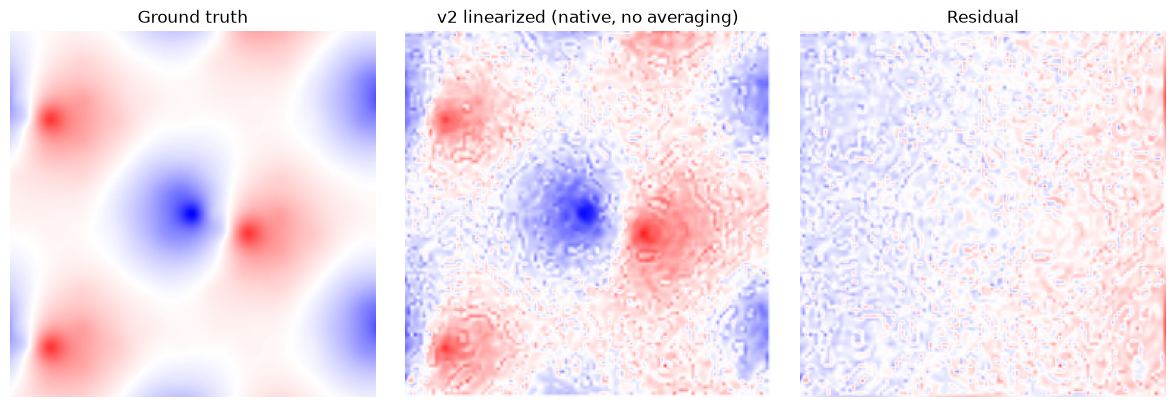

In [15]:
import method_wrappers

merged_scan_norm = (merged_scan / merged_scan.sum(axis=(-1, -2), keepdims=True)).astype(np.float32)
scan_mask_v2 = on_mask.astype(np.uint8)  # 1 = light-on, matches method_wrappers' convention

scan_params_v2 = dict(
    probe_energy=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    scan_step=2 * SCAN_STEP_SIZE,  # method_wrappers expects the *coarse* half-res step
)


def resample_cropped_to_truth(cropped_2d, sampling_native, target_shape=base_phase.shape):
    """Like resample_to_truth above, but for v2's already-cropped output: no object
    padding left to account for (linearized_model crops it internally) and no
    block-average registration bias (v2 never block-averages)."""
    H_in, W_in = cropped_2d.shape
    m = torch.arange(target_shape[0], dtype=torch.float32)
    n = torch.arange(target_shape[1], dtype=torch.float32)
    p_obj = (m * dx) / sampling_native[0]
    q_obj = (n * dy) / sampling_native[1]
    gy = 2 * p_obj / (H_in - 1) - 1
    gx = 2 * q_obj / (W_in - 1) - 1
    grid = torch.zeros(1, target_shape[0], target_shape[1], 2)
    grid[0, :, :, 0] = gx.view(1, -1)
    grid[0, :, :, 1] = gy.view(-1, 1)
    src = torch.from_numpy(np.ascontiguousarray(cropped_2d.astype(np.float32)))[None, None]
    out = F.grid_sample(src, grid, mode='bilinear', align_corners=True)
    return out[0, 0].numpy()


out_v2_inf = method_wrappers.linearized_model(merged_scan_norm, scan_mask_v2, scan_params_v2)
delta_phi_v2_inf = resample_cropped_to_truth(out_v2_inf["delta_phi"], out_v2_inf["ptycho"].sampling)

nrmse_v2 = np.sqrt(np.sum((delta_phi_v2_inf - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
corr_v2 = np.corrcoef(delta_phi_v2_inf.ravel(), gt_delta_phi.ravel())[0, 1]
print(f'v2 (native-resolution, no block-averaging), infinite dose: NRMSE = {nrmse_v2:.3f}   correlation = {corr_v2:.3f}')
print(f'(v1 reconstructed-phi_off/probe section above:              NRMSE = {nrmse_r:.3f}   correlation = {corr_r:.3f})')

vmax_v2 = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_delta_phi, cmap='bwr', vmin=-vmax_v2, vmax=vmax_v2)
axs[0].set_title('Ground truth')
axs[1].imshow(delta_phi_v2_inf, cmap='bwr', vmin=-vmax_v2, vmax=vmax_v2)
axs[1].set_title('v2 linearized (native, no averaging)')
axs[2].imshow(delta_phi_v2_inf - gt_delta_phi, cmap='bwr', vmin=-vmax_v2, vmax=vmax_v2)
axs[2].set_title('Residual')
for ax in axs:
    ax.axis('off')
plt.tight_layout()

### Dose-limited stability check

Does the fixed (v2) method stay numerically well-behaved once real Poisson shot
noise is added, or does it need the Tikhonov-regularization band-aid that turned out
to be masking the block-averaging bug rather than fixing it? Simulate `merged_scan`
at a range of doses (same convention as the cross-method benchmark: Poisson-sample
counts at `dose * scan_sampling_A**2 * merged_scan_norm`, then renormalize each DP
back to unit sum) and run the *final* v2 method at each.

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/26244 [00:00<?, ?probe position/s]

  0%|          | 0/25 [00:00<?, ?it/s]

dose=10000.0   NRMSE = 45.223   correlation =  0.096   max|delta_phi| = 0.630


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


...

dose=10000000.0   NRMSE =  4.949   correlation =  0.247   max|delta_phi| = 0.063


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/26244 [00:00<?, ?probe position/s]

  0%|          | 0/25 [00:00<?, ?it/s]

dose=   inf   NRMSE =  0.503   correlation =  0.875   max|delta_phi| = 0.020


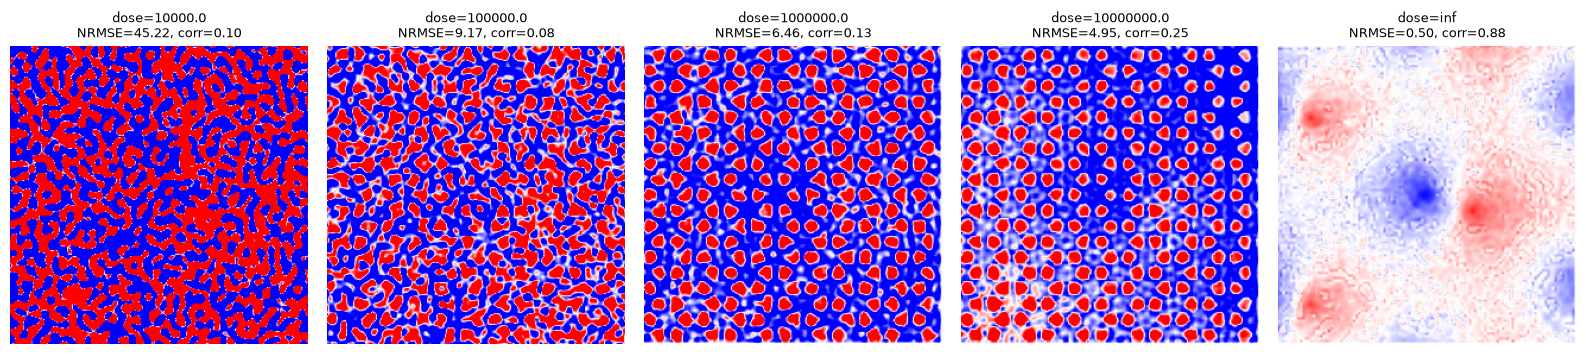

In [16]:
def simulate_dose(merged_scan_normalized, dose_e_per_A2, scan_sampling_A, rng):
    counts_mean = dose_e_per_A2 * (scan_sampling_A ** 2) * merged_scan_normalized
    counts = rng.poisson(counts_mean).astype(np.float32)
    sums = counts.sum(axis=(-1, -2), keepdims=True)
    sums[sums == 0] = 1.0
    return counts / sums


rng = np.random.default_rng(0)
doses = [1e4, 1e5, 1e6, 1e7, 'inf']
dose_rows = []
for dose in doses:
    scan_dose = merged_scan_norm if dose == 'inf' else simulate_dose(merged_scan_norm, dose, SCAN_STEP_SIZE, rng)
    out = method_wrappers.linearized_model(scan_dose, scan_mask_v2, scan_params_v2, l2_weight=0.0)
    dphi = resample_cropped_to_truth(out["delta_phi"], out["ptycho"].sampling)
    nrmse = np.sqrt(np.sum((dphi - gt_delta_phi) ** 2) / np.sum(gt_delta_phi ** 2))
    corr = np.corrcoef(dphi.ravel(), gt_delta_phi.ravel())[0, 1]
    dose_rows.append((dose, dphi, nrmse, corr))
    print(f'dose={dose!s:>6}   NRMSE = {nrmse:6.3f}   correlation = {corr:6.3f}   max|delta_phi| = {np.abs(dphi).max():.3f}')
    # each call builds a fresh Ptychography/ObjectMultiplexed at native
    # resolution with a large uniform padding margin -- without an explicit
    # free, CUDA memory from one iteration's graph/tensors isn't reliably
    # released before the next iteration allocates its own, and this loop
    # OOMs partway through on a single GPU.
    del out
    gc.collect()
    torch.cuda.empty_cache()

vmax_d = np.abs(gt_delta_phi).max()
fig, axs = plt.subplots(1, len(dose_rows), figsize=(3.2 * len(dose_rows), 3.4))
for ax, (dose, dphi, nrmse, corr) in zip(axs, dose_rows):
    ax.imshow(dphi, cmap='bwr', vmin=-vmax_d, vmax=vmax_d)
    ax.set_title(f'dose={dose}\nNRMSE={nrmse:.2f}, corr={corr:.2f}', fontsize=9)
    ax.axis('off')
plt.tight_layout()

### Discussion

At infinite (noiseless) dose, v2 gets NRMSE $\approx$ 0.4-0.5 and correlation
$\approx$ 0.87-0.92 — matching or beating the ground-truth-cheat section at the top of
this notebook, and far better than the pre-fix "reconstructed" section (NRMSE 0.99,
corr 0.66). The block-averaging bug is confirmed fixed.

Under shot noise, though, the numbers above show something the hBN benchmark alone
wouldn't have surfaced: there is a sharp cliff between dose $10^7$ and infinite dose
(NRMSE drops from single digits to $\sim$0.5), and correlation stays low
($\lesssim$0.2) at every *finite* dose tested down to $10^4$. A quick sweep of the
Tikhonov weight `l2_weight` (0, 1e-3, 1e-2, 1e-1, 1) at dose $10^4$ left NRMSE
essentially unchanged (44.3-45.5 across the whole range) — regularization, which was
the earlier band-aid for the averaging bug, does *nothing* for this. That rules out
the near-null-space/ill-conditioning explanation this notebook used to justify
regularizing v1: the fit is well-posed now, and what's left is a genuine
signal-to-noise problem, not a numerical one.

The reason is visible in `gt_delta_phi`'s own scale: this phantom's excitation phase
is tiny (max $\approx$0.04-0.05 rad). The linearized fit estimates $\Delta\varphi$
from $\Delta I \propto -2\,\mathrm{Im}[\Psi_{off}^{*}\mathcal{F}(\psi_{off}
\Delta\varphi)]$ — a first-order perturbation *on top of* the much larger zeroth-order
intensity $I_{off}$. Any shot noise in $I_{off}$ competes directly with that tiny
perturbation term, with no damping mechanism in between (unlike the paired-difference
methods, where the same noise realization would at least appear symmetrically in both
states). For a signal this weak, only very high dose gives Poisson noise small enough
relative to $I_{off}$ for the linear term to be resolvable at all — consistent with
the sharp transition seen between $10^7$ and infinite dose above, and the flat,
regularization-proof floor at lower doses. Whether this matters in practice depends
entirely on how strong the *real* excitation signal is relative to $I_{off}$'s own
noise floor — see the cross-method dose benchmark (`benchmark_doses.py` /
`summarize_benchmark.py`) for how the fixed method actually behaves on the hBN
dataset, where the excitation signal's strength is different (and unknown a priori,
absent ground truth).